In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('New Datasets/Expenditures Lok Sabha.csv')

# Convert the date column to datetime format
df['Expenditure Date'] = pd.to_datetime(df['Expenditure Date'], format='%d-%b-%Y', errors='coerce')


# Convert expenditure string to float and remove commas.
df['expenditure_amount']=df['Fund Disbursed Amount ( ₹ )'].str.replace(',','').astype(float)


train_end = int(0.8 * len(df))
val_end = int(0.9 * len(df))

# Split the DataFrame. Did this only for checking unsupervised learning doesnot require this.
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]


print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
train_df

Train shape: (47200, 12)
Validation shape: (5900, 12)
Test shape: (5901, 12)


,Sr. No.,State,Work,Work ID,IDA,MP Name,Constituency,Expenditure Date,Vendor Name,Payment Status,Fund Disbursed Amount ( ₹ ),expenditure_amount
0,1,Karnataka,"Construction of roads, link roads, pathways or...",WS/MP18263/2025-2026/173840,CHIKKAMAGALURU(DEPUTY COMMISSIONER CHIKMAGALUR),KOTA SRINIVAS POOJARY,UDUPI CHIKMAGALUR,2026-08-18,KRIDL BHUSIRI ACCOUNT WORKS,Payment In-Progress,75000,75000.0
1,2,Uttar Pradesh,"Construction of roads, link roads, pathways or...",WS/MP18218/2025-2026/233777,GHAZIABAD(DISTRICT MAGISTRAE GHAZIABAD_IDA),ATUL GARG,GHAZIABAD,2026-08-21,DARSH BUILDCON,Payment In-Progress,799146,799146.0
2,3,Uttar Pradesh,"Construction of roads, link roads, pathways or...",WS/MP18218/2025-2026/233878,GHAZIABAD(DISTRICT MAGISTRAE GHAZIABAD_IDA),ATUL GARG,GHAZIABAD,2026-08-04,DARSH BUILDCON,Payment In-Progress,832080,832080.0
3,4,Uttar Pradesh,"Construction of roads, link roads, pathways or...",WS/MP18218/2025-2026/233781,GHAZIABAD(DISTRICT MAGISTRAE GHAZIABAD_IDA),ATUL GARG,GHAZIABAD,2026-08-04,DARSH BUILDCON,Payment In-Progress,498309,498309.0
4,5,Odisha,Construction of community centers and communit...,WS/MP18142/2025-2026/185341,PURI(DISTRICT COLLECTOR PURI_IDA),BIBHU PRASAD TARAI,JAGATSINGHPUR(SC),2026-08-28,MEMBER SECY OB AND OC WWB BBSR,Payment In-Progress,2000,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
47195,47196,Rajasthan,Development of playground,WS/MP18162/2025-2026/231140,BHILWARA(DISTRICT COLLECTOR BHILWARA_IDA),DAMODAR AGARWAL,BHILWARA,2026-02-13,DEVNARYAN ENTERPRISES,Payment Success,489600,489600.0
47196,47197,Odisha,Providing drains and gutters for public drainage,WS/MP18139/2025-2026/202059,Baragada(DISTRICT COLLECTOR BARAGARH_IDA),PRADEEP PUROHIT,BARGARH,2026-01-20,BIJEPI BAGH,Payment Success,200000,200000.0
47197,47198,Odisha,Construction of common work sheds/ common cove...,WS/MP18139/2025-2026/202040,Baragada(DISTRICT COLLECTOR BARAGARH_IDA),PRADEEP PUROHIT,BARGARH,2026-02-11,BIJEPI BAGH,Payment Success,435901,435901.0
47198,47199,Odisha,Construction of common work sheds/ common cove...,WS/MP18139/2025-2026/202033,Baragada(DISTRICT COLLECTOR BARAGARH_IDA),PRADEEP PUROHIT,BARGARH,2026-02-17,BIJEPI BAGH,Payment Success,300000,300000.0


In [11]:
df=df[:-1]
df.loc[df['expenditure_amount'].idxmax()]

Sr. No.                                                               5287
State                                                        Uttar Pradesh
Work                                             Lighting of public spaces
Work ID                                        WS/MP18233/2026-2027/274638
IDA                            PRAYAGRAJ(DISTRICT MAGISTRAE ALLAHABAD_IDA)
MP Name                                                      PRAVEEN PATEL
Constituency                                                       PHULPUR
Expenditure Date                                       2026-07-01 00:00:00
Vendor Name                                           Roudrantak Infratech
Payment Status                                             Payment Success
Fund Disbursed Amount ( ₹ )                                       20786350
expenditure_amount                                              20786350.0
Name: 5286, dtype: object

In [4]:
df[df['Expenditure Date']=='NaT']

,Sr. No.,State,Work,Work ID,IDA,MP Name,Constituency,Expenditure Date,Vendor Name,Payment Status,Fund Disbursed Amount ( ₹ ),expenditure_amount


In [5]:
thresholds = [50000, 500000, 5000000]
expenditures=train_df['Fund Disbursed Amount ( ₹ )'].str.replace(',','').astype(float)
for amount in expenditures:
    candidates = [t for t in thresholds if amount <= t]
    if not candidates:
        print(0)
        continue
    nearest = min(candidates)
    gap_fraction = (nearest - amount) / nearest
    print(round(100 * np.exp(-gap_fraction / 0.05), 2))

0.0
0.0
0.0
93.46
0.0
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.39
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
62.28
0.0
0.0
0.0
0.0
0.67
0.0
0.25
0.0
0.0
0.67
0.0
6.08
11.67
0.0
0.0
0.0
0.0
0.0
83.44
92.86
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.25
0.0
0.0
100.0
0.03
1.54
1.83
0.0
0.0
0.19
0.0
0.0
0.0
0.0
0.0
0.0
0.02
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.04
2.11
0.86
0.86
81.48
0.0
0.0
1.83
0.83
0.0
0.0
0.0
0.0
72.61
72.61
72.61
72.61
72.61
72.61
6.2
1.85
12.2
31.29
0.28
80.25
0.72
4.76
0
0.0
0.0
0.0
1.46
0.0
1.82
0.0
0.0
0.0
0

In [6]:
proximity_df=pd.read_csv('New Datasets/Proximity.csv')

proximity_df['Expenditure']=train_df['expenditure_amount']

<Axes: xlabel='Expenditure', ylabel='Proximity'>

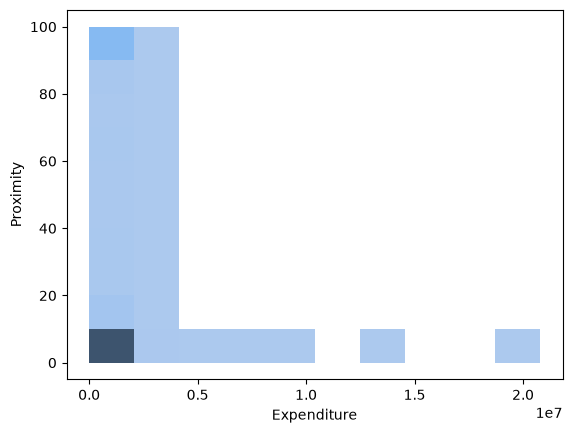

In [7]:
sns.histplot(data=proximity_df,x='Expenditure',y='Proximity',bins=10)

In [8]:
vendorDf=train_df.copy()
vendorDf["vendor_payout_velocity"] = 0
vendorDf["vendor_cumulative_30d"] = 0.0
for (mp, vendor), group in train_df.groupby(["MP Name", "Vendor Name"]):
    idx = group.index
    dates = group["Expenditure Date"].values
    amounts = group['expenditure_amount'].values
    counts, sums = [], []
    for i, d in enumerate(dates):
        window_start = d - np.timedelta64(30, "D")
        in_window = (dates > window_start) & (dates <= d)
        counts.append(np.sum(in_window))
        sums.append(amounts[in_window].sum())
    vendorDf.loc[idx, "vendor_payout_velocity"] = counts
    vendorDf.loc[idx, "vendor_cumulative_30d"] = sums
vendorDf

,Sr. No.,State,Work,Work ID,IDA,MP Name,Constituency,Expenditure Date,Vendor Name,Payment Status,Fund Disbursed Amount ( ₹ ),expenditure_amount,vendor_payout_velocity,vendor_cumulative_30d
0,1,Karnataka,"Construction of roads, link roads, pathways or...",WS/MP18263/2025-2026/173840,CHIKKAMAGALURU(DEPUTY COMMISSIONER CHIKMAGALUR),KOTA SRINIVAS POOJARY,UDUPI CHIKMAGALUR,2026-08-18,KRIDL BHUSIRI ACCOUNT WORKS,Payment In-Progress,75000,75000.0,1,75000.0
1,2,Uttar Pradesh,"Construction of roads, link roads, pathways or...",WS/MP18218/2025-2026/233777,GHAZIABAD(DISTRICT MAGISTRAE GHAZIABAD_IDA),ATUL GARG,GHAZIABAD,2026-08-21,DARSH BUILDCON,Payment In-Progress,799146,799146.0,3,2129535.0
2,3,Uttar Pradesh,"Construction of roads, link roads, pathways or...",WS/MP18218/2025-2026/233878,GHAZIABAD(DISTRICT MAGISTRAE GHAZIABAD_IDA),ATUL GARG,GHAZIABAD,2026-08-04,DARSH BUILDCON,Payment In-Progress,832080,832080.0,2,1330389.0
3,4,Uttar Pradesh,"Construction of roads, link roads, pathways or...",WS/MP18218/2025-2026/233781,GHAZIABAD(DISTRICT MAGISTRAE GHAZIABAD_IDA),ATUL GARG,GHAZIABAD,2026-08-04,DARSH BUILDCON,Payment In-Progress,498309,498309.0,2,1330389.0
4,5,Odisha,Construction of community centers and communit...,WS/MP18142/2025-2026/185341,PURI(DISTRICT COLLECTOR PURI_IDA),BIBHU PRASAD TARAI,JAGATSINGHPUR(SC),2026-08-28,MEMBER SECY OB AND OC WWB BBSR,Payment In-Progress,2000,2000.0,1,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47195,47196,Rajasthan,Development of playground,WS/MP18162/2025-2026/231140,BHILWARA(DISTRICT COLLECTOR BHILWARA_IDA),DAMODAR AGARWAL,BHILWARA,2026-02-13,DEVNARYAN ENTERPRISES,Payment Success,489600,489600.0,1,489600.0
47196,47197,Odisha,Providing drains and gutters for public drainage,WS/MP18139/2025-2026/202059,Baragada(DISTRICT COLLECTOR BARAGARH_IDA),PRADEEP PUROHIT,BARGARH,2026-01-20,BIJEPI BAGH,Payment Success,200000,200000.0,1,200000.0
47197,47198,Odisha,Construction of common work sheds/ common cove...,WS/MP18139/2025-2026/202040,Baragada(DISTRICT COLLECTOR BARAGARH_IDA),PRADEEP PUROHIT,BARGARH,2026-02-11,BIJEPI BAGH,Payment Success,435901,435901.0,2,635901.0
47198,47199,Odisha,Construction of common work sheds/ common cove...,WS/MP18139/2025-2026/202033,Baragada(DISTRICT COLLECTOR BARAGARH_IDA),PRADEEP PUROHIT,BARGARH,2026-02-17,BIJEPI BAGH,Payment Success,300000,300000.0,3,935901.0


In [9]:
allocatedDf=pd.read_csv('New Datasets/Allocated Limit MP Lok Sabha.csv')

result_dict=dict(zip(allocatedDf['MP Name'],allocatedDf['Allocated Amount in rupees'].str.replace(',','').astype(float)))

result_dict

{'AASHTIKAR PATIL NAGESH BAPURAO': 190289442.0,
 'ABDUL RASHID SHEIKH': 154773472.11,
 'ABHAY KUMAR SINHA': 147000000.0,
 'ABHIJIT GANGOPADHYAY': 147000000.0,
 'Abu Taher Khan': 147000000.0,
 'ADHIKARI SOUMENDU': 147000000.0,
 'ADITYA YADAV': 147000000.0,
 'Adv Adoor Prakash': 147000000.0,
 'Adv Dean Kuriakose': 147000000.0,
 'ADV GOWAAL KAGADA PADAVI': 147816309.11,
 'ADV K FRANCIS GEORGE': 188722256.11,
 'AFZAL ANSARI': 220500000.0,
 'AGA SYED RUHULLAH MEHDI': 147000000.0,
 'Ajay Bhatt': 147000000.0,
 'Ajay Kumar Mandal': 147000000.0,
 'Ajay Tamta': 147000000.0,
 'AJENDRA SINGH LODHI': 147000000.0,
 'AKHILESH YADAV': 147000000.0,
 'AKSHAYA YADAV': 147000000.0,
 'ALFRED KANNGAM S ARTHUR': 147000000.0,
 'Alok Kumar Suman': 147000000.0,
 'ALOK SHARMA': 147000000.0,
 'AMAR SHARADRAO KALE': 147000000.0,
 'AMARSING TISSO': 147000000.0,
 'AMBICA G LAKSHMINARAYANA VALMIKI': 201899064.11,
 'Amol Ramsing Kolhe': 147000000.0,
 'AMRARAM': 165691544.11,
 'AMRINDER SINGH RAJA WARRING': 147000000.0